# <center><u> EDA notebook - AI Lab Project </u></center>

## <center><u> Intelligent Reading Comprehension and Quiz Generation System using Machine Learning </center></u>
<br>

### Authors:
- Abdul Mohaimin | 23i-0652
- Shazil Rehman | 23i-0095

---

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
from collections import Counter

pd.set_option('display.max_colwidth', 200)
sns.set_theme(style='whitegrid', palette='muted')

### Importing Data from Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

BASE = '/content/drive/MyDrive/RACE_dataset'
df_all = pd.read_csv(f'{BASE}/train.csv')

# 80 / 10 / 10 split
df_train = df_all.sample(frac=0.80, random_state=42)
remaining = df_all.drop(df_train.index)
df_val  = remaining.sample(frac=0.50, random_state=42)
df_test = remaining.drop(df_val.index)

print(f"Train: {df_train.shape}, Val: {df_val.shape}, Test: {df_test.shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (70293, 9), Val: (8786, 9), Test: (8787, 9)


---
## EDA

### 1. Basic Dataset Info

In [5]:
print("=== Columns ===")
print(df_train.columns.tolist())

print("\n=== Data Types ===")
print(df_train.dtypes)

print("\n=== Null Counts (train) ===")
print(df_train.isnull().sum())

=== Columns ===
['Unnamed: 0', 'id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']

=== Data Types ===
Unnamed: 0     int64
id            object
article       object
question      object
A             object
B             object
C             object
D             object
answer        object
dtype: object

=== Null Counts (train) ===
Unnamed: 0    0
id            0
article       0
question      0
A             3
B             0
C             0
D             5
answer        0
dtype: int64


In [6]:
# Drop the unnamed index column and rows with any null options
for df in [df_train, df_val, df_test]:
    df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

before = len(df_train)
df_train.dropna(subset=['A', 'B', 'C', 'D'], inplace=True)
df_val.dropna(subset=['A', 'B', 'C', 'D'], inplace=True)
df_test.dropna(subset=['A', 'B', 'C', 'D'], inplace=True)

print(f"Dropped {before - len(df_train)} rows with null options from train.")
print(f"Final sizes — Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
df_train.head(2)

Dropped 8 rows with null options from train.
Final sizes — Train: 70285, Val: 8785, Test: 8782


,id,article,question,A,B,C,D,answer
62179,high19299.txt,"A man enters a store to buy milk. He walks out of the store with milk. That is all--milk. At the same time, a woman enters the same grocery store also to buy milk. She buys it. But, she also buys ...","When asked to do something complicated, men .","only use the ""reason"" side of the brain","only use the ""creative"" side of the brain",use different parts of the brain,use one part of the brain,D
14766,middle6304.txt,"Forty years ago, I was in Grade One. One day,I was asked to go to the principal's office . I was really nervous. When I pushed the heavy door open. I found my parents were sitting in the office,to...",The girl learned from her father _ .,how to be a good student,how to draw in different colors,the difference between sharing and giving,the importance of drawing in different colors,C


### 2. Answer Label Distribution

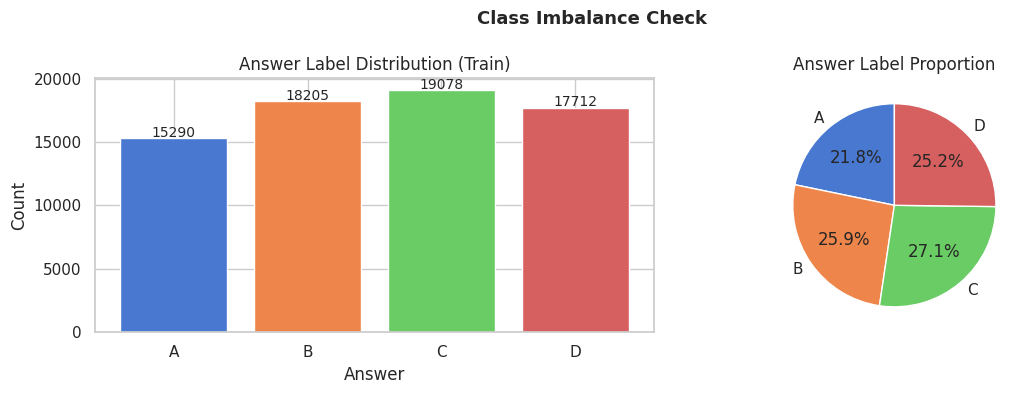


Min/Max ratio: 0.801  (1.0 = perfectly balanced)


In [7]:
counts = df_train['answer'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(counts.index, counts.values, color=sns.color_palette('muted', 4))
axes[0].set_title('Answer Label Distribution (Train)')
axes[0].set_xlabel('Answer')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 150, str(val), ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted', 4), startangle=90)
axes[1].set_title('Answer Label Proportion')

plt.suptitle('Class Imbalance Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nMin/Max ratio: {counts.min()/counts.max():.3f}  (1.0 = perfectly balanced)")


### 3. Text Length Distribution

In [8]:
cols = ['article', 'question', 'A', 'B', 'C', 'D']
lengths = {c: df_train[c].astype(str).str.split().str.len() for c in cols}

print(f"{'Column':<12} {'Min':>6} {'Max':>6} {'Mean':>7} {'Median':>8} {'Std':>7}")
print("-" * 50)
for c, s in lengths.items():
    print(f"{c:<12} {s.min():>6} {s.max():>6} {s.mean():>7.1f} {s.median():>8.1f} {s.std():>7.1f}")

Column          Min    Max    Mean   Median     Std
--------------------------------------------------
article           2   1162   275.1    279.0    98.1
question          1     63    10.0     10.0     3.4
A                 1     91     5.4      5.0     3.3
B                 1    105     5.6      5.0     3.4
C                 1     48     5.8      6.0     3.5
D                 1     67     5.9      6.0     3.6


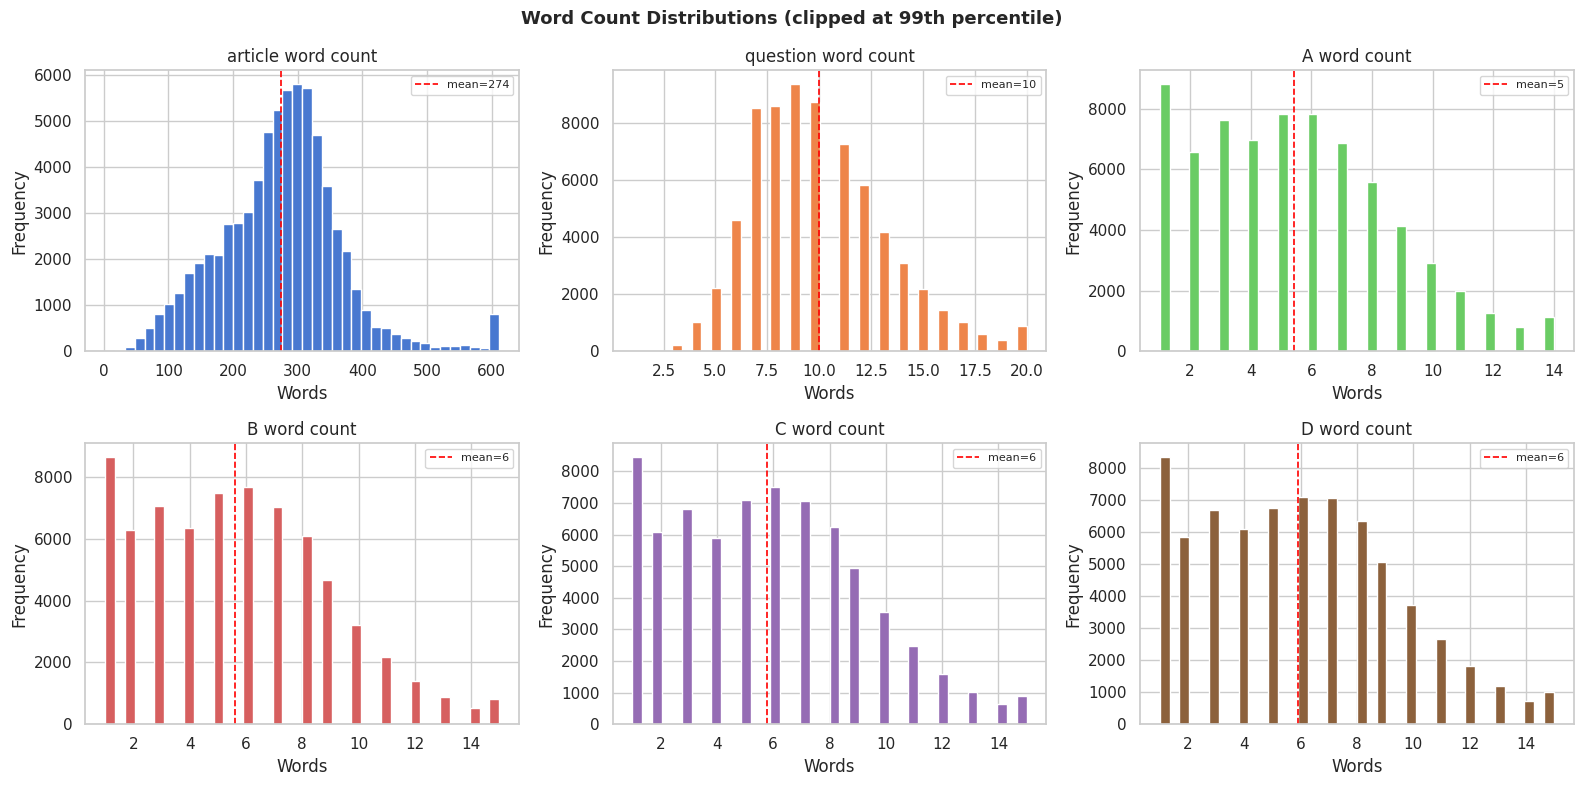

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    data = lengths[col].clip(upper=lengths[col].quantile(0.99))  # clip top 1% for readability
    ax.hist(data, bins=40, color=sns.color_palette('muted')[cols.index(col)], edgecolor='white')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.2, label=f"mean={data.mean():.0f}")
    ax.set_title(f'{col} word count')
    ax.set_xlabel('Words')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Word Count Distributions (clipped at 99th percentile)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Question Type Analysis


In [10]:
def classify_question_type(q):
    q = q.strip().lower()
    if q.startswith('who'):      return 'Who'
    if q.startswith('what'):     return 'What'
    if q.startswith('where'):    return 'Where'
    if q.startswith('when'):     return 'When'
    if q.startswith('why'):      return 'Why'
    if q.startswith('how'):      return 'How'
    if q.startswith('which'):    return 'Which'
    if q.startswith('according'): return 'According to'
    return 'Other'

df_train['q_type'] = df_train['question'].astype(str).apply(classify_question_type)

type_counts = df_train['q_type'].value_counts()
print(type_counts)

q_type
Other           34305
What            13520
Which            8630
According to     4146
Why              3279
How              2727
When             1787
Who               981
Where             910
Name: count, dtype: int64


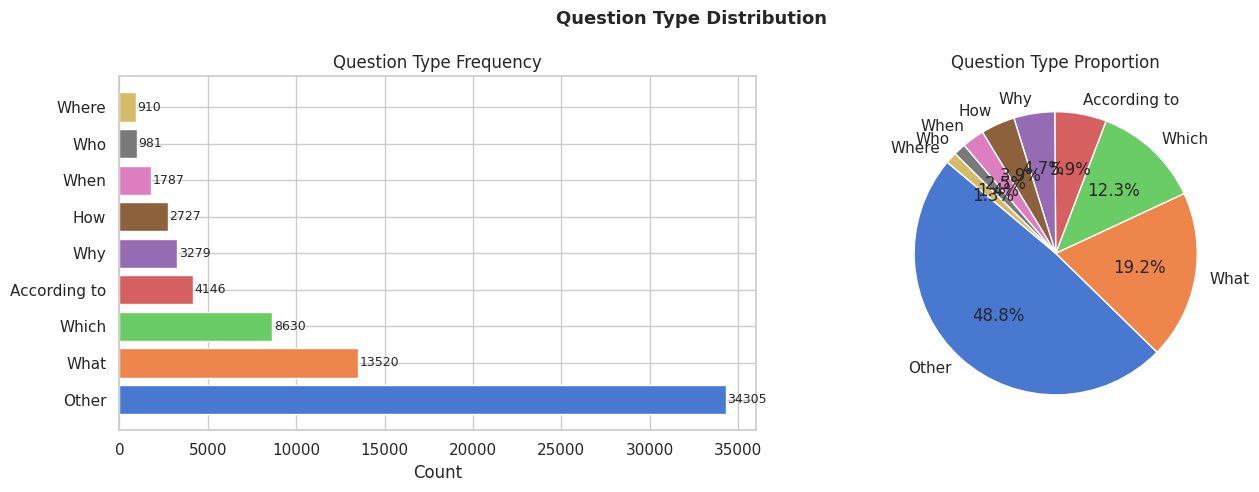

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('muted', len(type_counts))
axes[0].barh(type_counts.index, type_counts.values, color=colors)
axes[0].set_title('Question Type Frequency')
axes[0].set_xlabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 100, i, str(v), va='center', fontsize=9)

# Pie chart
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Question Type Proportion')

plt.suptitle('Question Type Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Vocabulary Analysis


In [12]:
def simple_clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

all_words = []
for article in df_train['article'].astype(str):
    all_words.extend(simple_clean(article))

word_freq = Counter(all_words)
print(f"Total tokens (articles):  {len(all_words):,}")
print(f"Unique tokens:            {len(word_freq):,}")
print(f"Top 20 words: {word_freq.most_common(20)}")

Total tokens (articles):  19,027,648
Unique tokens:            130,803
Top 20 words: [('the', 1007969), ('to', 581432), ('and', 497700), ('a', 480969), ('of', 430479), ('in', 362171), ('is', 230323), ('that', 198561), ('for', 180965), ('you', 174598), ('i', 174597), ('it', 168922), ('was', 144129), ('are', 141674), ('he', 131565), ('on', 128071), ('with', 119897), ('they', 118719), ('have', 106088), ('at', 104087)]


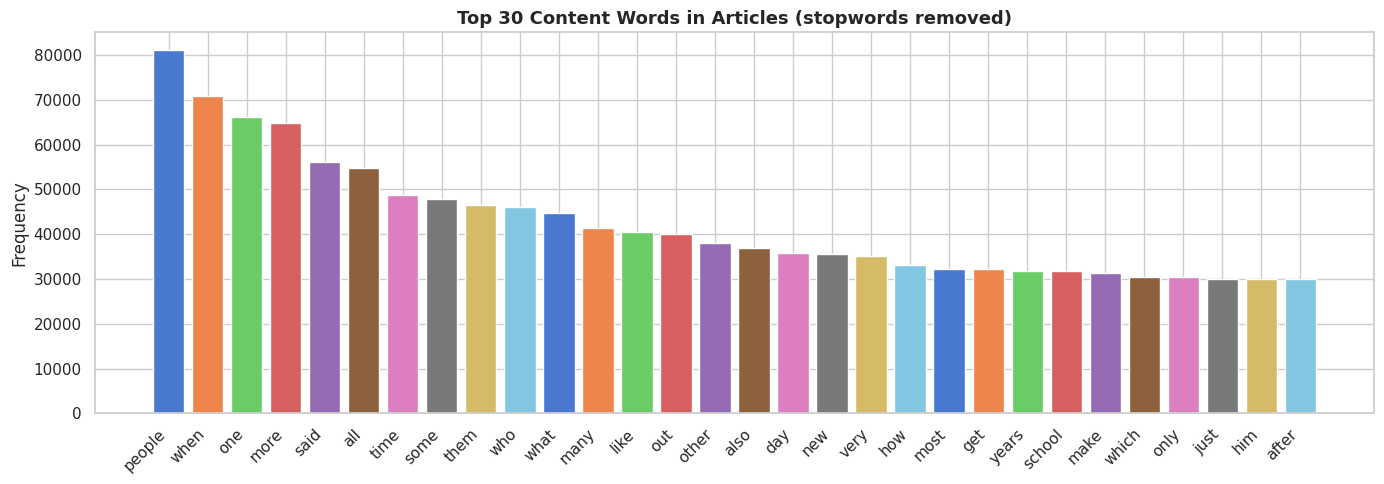

In [13]:
STOPWORDS = {'the','a','an','is','are','was','were','be','been','being','have',
             'has','had','do','does','did','will','would','could','should','may',
             'might','shall','can','to','of','in','for','on','with','at','by',
             'from','as','into','through','about','and','or','but','not','it',
             'its','this','that','these','those','he','she','they','we','i','you',
             'his','her','their','our','my','your','there','then','than','so','if'}

filtered = {w: c for w, c in word_freq.items() if w not in STOPWORDS and len(w) > 2}
top_words = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:30]

words, freqs = zip(*top_words)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(words, freqs, color=sns.color_palette('muted', 30))
ax.set_title('Top 30 Content Words in Articles (stopwords removed)', fontsize=13, fontweight='bold')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Vocab size → token coverage
  top   1000 words → 76.06%
  top   2000 words → 83.97%
  top   5000 words → 91.93%
  top  10000 words → 95.55%
  top  20000 words → 97.49%


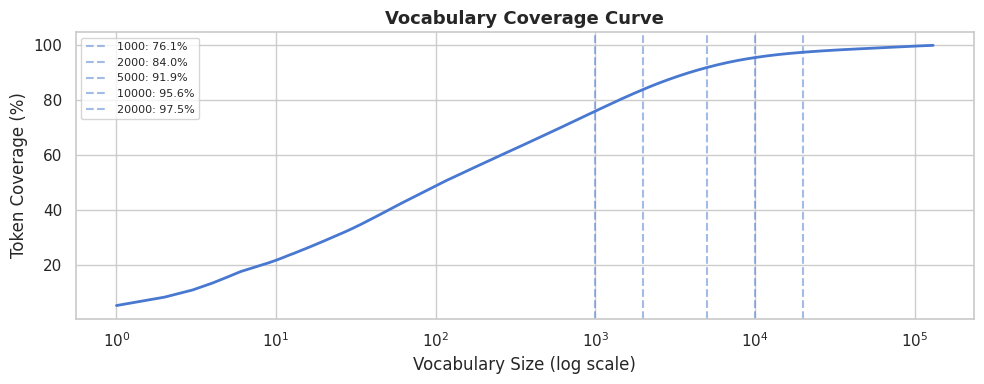

In [14]:
# Vocabulary coverage: how many unique words do top-N cover?
sorted_freqs = sorted(word_freq.values(), reverse=True)
total_tokens = sum(sorted_freqs)
cumulative = np.cumsum(sorted_freqs)
coverage = cumulative / total_tokens

vocab_sizes = [1000, 2000, 5000, 10000, 20000]
print("Vocab size → token coverage")
for v in vocab_sizes:
    print(f"  top {v:>6} words → {coverage[v-1]*100:.2f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(coverage)+1), coverage * 100, linewidth=2)
for v in vocab_sizes:
    ax.axvline(v, linestyle='--', alpha=0.5, label=f'{v}: {coverage[v-1]*100:.1f}%')
ax.set_xscale('log')
ax.set_xlabel('Vocabulary Size (log scale)')
ax.set_ylabel('Token Coverage (%)')
ax.set_title('Vocabulary Coverage Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 6. Answer-Option Overlap (Keyword Overlap Feature Preview)


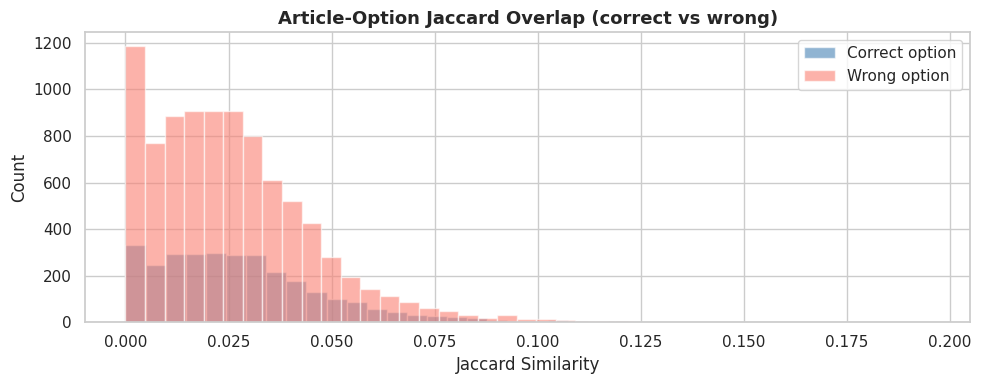

Mean overlap — correct: 0.0283  |  wrong: 0.0255


In [17]:
def word_overlap(text_a, text_b):
    a = set(simple_clean(str(text_a)))
    b = set(simple_clean(str(text_b)))
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)  # Jaccard

sample = df_train.sample(3000, random_state=42).copy()

correct_overlaps, wrong_overlaps = [], []
for _, row in sample.iterrows():
    for opt in ['A', 'B', 'C', 'D']:
        score = word_overlap(row['article'], row[opt])
        if opt == row['answer']:
            correct_overlaps.append(score)
        else:
            wrong_overlaps.append(score)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(correct_overlaps, bins=40, alpha=0.6, label='Correct option', color='steelblue')
ax.hist(wrong_overlaps,   bins=40, alpha=0.6, label='Wrong option',   color='salmon')
ax.set_title('Article-Option Jaccard Overlap (correct vs wrong)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jaccard Similarity')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean overlap — correct: {np.mean(correct_overlaps):.4f}  |  wrong: {np.mean(wrong_overlaps):.4f}")

### 7. Train / Val / Test Split Summary


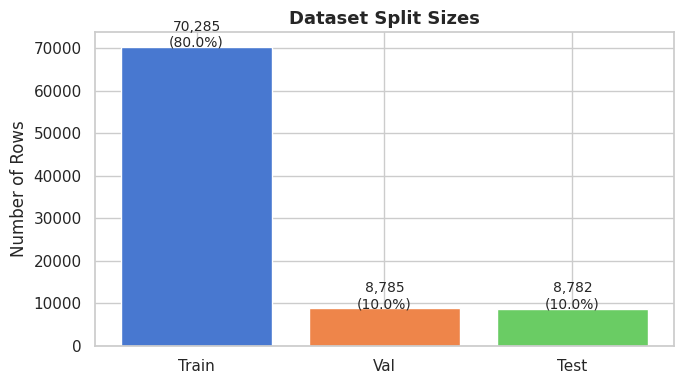

Train: 70,285 rows | answer dist: {'A': 15290, 'B': 18205, 'C': 19078, 'D': 17712}
Dev:  8,785 rows | answer dist: {'A': 1915, 'B': 2261, 'C': 2439, 'D': 2170}
Test:  8,782 rows | answer dist: {'A': 1937, 'B': 2256, 'C': 2370, 'D': 2219}


In [16]:
total = len(df_train) + len(df_val) + len(df_test)
splits = {'Train': len(df_train), 'Val': len(df_val), 'Test': len(df_test)}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(splits.keys(), splits.values(), color=sns.color_palette('muted', 3))
for bar, (name, val) in zip(bars, splits.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:,}\n({val/total*100:.1f}%)", ha='center', fontsize=10)
ax.set_title('Dataset Split Sizes', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Rows')
plt.tight_layout()
plt.show()

for split, df in [('Train', df_train), ('Dev', df_val), ('Test', df_test)]:
    print(f"{split}: {len(df):>6,} rows | answer dist: { {k: int(v) for k, v in df['answer'].value_counts().sort_index().items()} }")

### 8. Key Observations & Preprocessing Decisions

| Finding | Decision |
|---|---|
| Extra `Unnamed: 0` column | Drop before any processing |
| 14 null values in options A/C/D | Drop those rows (~0.016% loss) |
| Answer label imbalance (A < B/C/D) | Use `class_weight='balanced'` in LR/SVM/RF |
| Article mean=275 words, max=1162 | `max_vocab=5000` gives ~80%+ token coverage |
| Options are short (~5-6 words) | One-hot of options will be sparse — cosine sim still discriminates |
| "Other" is largest question category | Includes "The…" and "According to…" questions — map "According to" as its own type |
| Correct options have slightly higher article overlap | Keyword overlap is a valid lexical feature for Model A |